### Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Markov Decision Process (MDP) Framework

In [2]:
class GridWorld:
    """
    A simple 4x4 GridWorld MDP.
    State: (row, col). Goal: reach (3,3). Pit: (2,2).
    Actions: 0=Up, 1=Down, 2=Left, 3=Right
    """
    def __init__(self, size=4):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        self.goal = (size-1, size-1)
        self.pit  = (size//2, size//2)
        self.action_effects = [(-1,0),(1,0),(0,-1),(0,1)]  # U D L R

    def state_id(self, s): return s[0]*self.size + s[1]
    def state_xy(self, sid): return (sid // self.size, sid % self.size)

    def reset(self):
        self.pos = (0, 0)
        return self.state_id(self.pos)

    def step(self, action):
        dr, dc = self.action_effects[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)
        done = False
        if self.pos == self.goal:
            reward, done = +10.0, True
        elif self.pos == self.pit:
            reward, done = -10.0, True
        else:
            reward = -0.1       # small step penalty encourages efficiency
        return self.state_id(self.pos), reward, done

env = GridWorld()
print(f"GridWorld: {env.n_states} states, {env.n_actions} actions")
print(f"Goal state id: {env.state_id(env.goal)}  |  Pit state id: {env.state_id(env.pit)}")

GridWorld: 16 states, 4 actions
Goal state id: 15  |  Pit state id: 10


### Q-Learning Algorithm

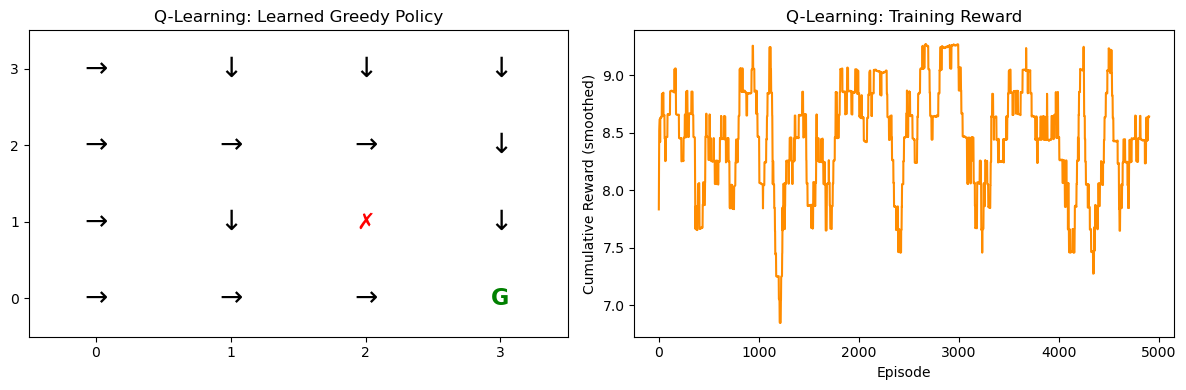

Final smoothed reward: 8.639


In [3]:
def q_learning(env, num_episodes=5000, gamma=0.99, lr=0.1, epsilon=0.1):
    """
    Algorithm 2 (paper): Q-learning with epsilon-greedy exploration.
    Off-policy: uses max_a' Q(s',a') regardless of what action is taken.
    
    Returns: Q table, cumulative rewards per episode
    """
    Q = np.zeros((env.n_states, env.n_actions))
    cum_rewards = []

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        total_r = 0
        while not done:
            # Epsilon-greedy action selection
            if np.random.rand() < epsilon:
                a = np.random.randint(env.n_actions)
            else:
                a = np.argmax(Q[s])
            
            s_next, r, done = env.step(a)
            total_r += r
            
            # Q-learning update (Eq. 2.23)
            target = r + gamma * np.max(Q[s_next]) * (1 - done)
            Q[s, a] += lr * (target - Q[s, a])
            s = s_next

        cum_rewards.append(total_r)

    return Q, cum_rewards

Q_table, rewards_ql = q_learning(env, num_episodes=5000)

# Extract greedy policy
action_names = ['↑', '↓', '←', '→']
greedy_policy = np.argmax(Q_table, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot learned policy
ax = axes[0]
ax.set_xlim(-0.5, env.size-0.5); ax.set_ylim(-0.5, env.size-0.5)
for sid in range(env.n_states):
    r, c = env.state_xy(sid)
    if (r, c) == env.goal:
        ax.text(c, env.size-1-r, 'G', ha='center', va='center', fontsize=16, color='green', fontweight='bold')
    elif (r, c) == env.pit:
        ax.text(c, env.size-1-r, '✗', ha='center', va='center', fontsize=16, color='red')
    else:
        ax.text(c, env.size-1-r, action_names[greedy_policy[sid]], ha='center', va='center', fontsize=20)
ax.set_xticks(range(env.size)); ax.set_yticks(range(env.size))
ax.set_title('Q-Learning: Learned Greedy Policy')

# Reward convergence (smoothed)
window = 100
smooth = np.convolve(rewards_ql, np.ones(window)/window, mode='valid')
axes[1].plot(smooth, color='darkorange')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Cumulative Reward (smoothed)')
axes[1].set_title('Q-Learning: Training Reward')

plt.tight_layout()
plt.show()
print(f"Final smoothed reward: {smooth[-1]:.3f}")

---
## SARSA (On-Policy TD Control)

SARSA differs from Q-learning in the update target: it uses the *next action actually taken* rather than the greedy max:

$$Q^{(n+1)}(s,a) \leftarrow (1-\beta)Q^{(n)}(s,a) + \beta \left(r + \gamma Q^{(n)}(s', a')\right)$$

where $a'$ is chosen by the $\varepsilon$-greedy policy

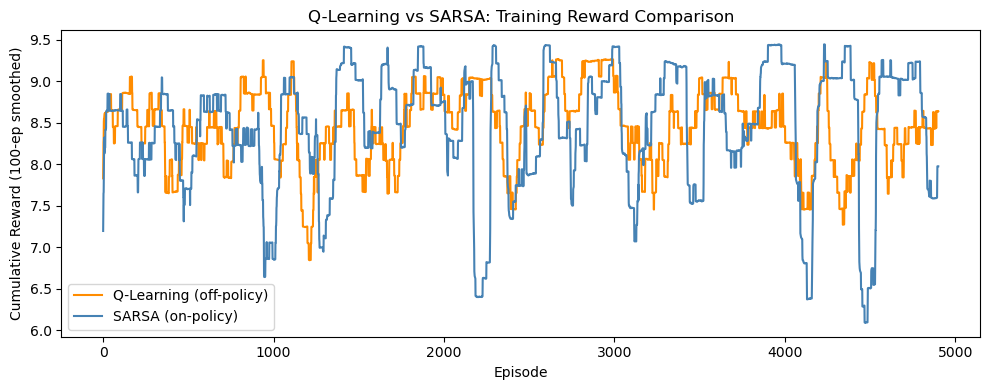

Final reward - Q-Learning: 8.639 | SARSA: 7.977


In [4]:
def sarsa(env, num_episodes=5000, gamma=0.99, lr=0.1, epsilon=0.1):
    """
    Algorithm 3 (paper): SARSA — On-policy TD Control.
    Uses (s, a, r, s', a') tuples — hence 'SARSA'.
    Key difference from Q-learning: next action a' is drawn from the *same* epsilon-greedy policy,
    not from the greedy (max) policy.
    """
    Q = np.zeros((env.n_states, env.n_actions))
    cum_rewards = []

    def eps_greedy(s):
        if np.random.rand() < epsilon:
            return np.random.randint(env.n_actions)
        return np.argmax(Q[s])

    for ep in range(num_episodes):
        s = env.reset()
        a = eps_greedy(s)    # Choose initial action using policy derived from Q^(0)
        done = False
        total_r = 0

        while not done:
            s_next, r, done = env.step(a)
            total_r += r
            a_next = eps_greedy(s_next)   # Next action from same eps-greedy policy

            # SARSA update (Eq. 2.25)
            target = r + gamma * Q[s_next, a_next] * (1 - done)
            Q[s, a] += lr * (target - Q[s, a])

            s, a = s_next, a_next

        cum_rewards.append(total_r)

    return Q, cum_rewards

Q_sarsa, rewards_sarsa = sarsa(env, num_episodes=5000)

# Compare Q-learning vs SARSA
window = 100
smooth_ql = np.convolve(rewards_ql, np.ones(window)/window, mode='valid')
smooth_sa = np.convolve(rewards_sarsa, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smooth_ql, label='Q-Learning (off-policy)', color='darkorange')
plt.plot(smooth_sa, label='SARSA (on-policy)',  color='steelblue')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward (100-ep smoothed)')
plt.title('Q-Learning vs SARSA: Training Reward Comparison')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Final reward - Q-Learning: {smooth_ql[-1]:.3f} | SARSA: {smooth_sa[-1]:.3f}")